# **Brecha salarial por sexo: un miniestudio con datos reales**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franperezec/propedeutico-flacso/blob/main/clases/analitica_datos/brecha_salarial.ipynb)

**Profesor:** Francisco Pérez M. · **Propedéutico de Matemáticas y Programación · FLACSO Ecuador**

---

**Pregunta guía:** ¿ganan lo mismo hombres y mujeres que tienen la misma educación y la misma experiencia?

Para responderla vamos a recorrer, en 20 minutos, el flujo completo de un estudio empírico:

$$\text{datos reales} \;\to\; \text{descriptivos} \;\to\; \text{regresión (MCO con matrices)} \;\to\; \text{librería profesional} \;\to\; \text{interpretación}$$

Todo lo que usaremos ya lo conocen: Pandas, NumPy, álgebra de matrices y gráficos. La única novedad es verlo funcionar junto, sobre una pregunta económica real.

## Objetivos de aprendizaje

Al finalizar, el estudiante podrá:

- cargar y describir una base de datos real con Pandas (`read_csv`, `describe`, `groupby`);
- comparar la distribución de una variable **condicionada a un grupo**: medias, varianzas, histogramas y boxplots por sexo;
- plantear MCO como un **problema de optimización** y calcular $\hat{\beta}=(X'X)^{-1}X'y$ con NumPy;
- verificar el resultado con `statsmodels` e interpretar coeficientes *manteniendo lo demás constante*;
- distinguir entre brecha condicionada y evidencia causal de discriminación.

> **Nivel:** introductorio. Cada paso usa herramientas ya vistas en el módulo; la novedad es integrarlas en un estudio completo.

## Preparación del entorno

### Google Colab

Las bibliotecas suelen estar instaladas. Si aparece un error, ejecute una sola vez:

```python
%pip install numpy pandas matplotlib statsmodels
```

### VS Code

**Windows — PowerShell**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install numpy pandas matplotlib statsmodels ipykernel
```

**macOS o Linux**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install numpy pandas matplotlib statsmodels ipykernel
```

En VS Code, abra el notebook y seleccione como kernel el intérprete de `.venv`. Si clonaste el repositorio del curso e instalaste `requirements.txt`, ya tienes todo lo necesario.

### Extensiones recomendadas para trabajar con datos (opcionales)

En VS Code, dos extensiones hacen más cómodo el trabajo con bases de datos como la de hoy (se instalan desde la pestaña **Extensiones**, `Ctrl+Shift+X`):

- **Data Wrangler** (de Microsoft): abre cualquier DataFrame de Pandas en una vista interactiva para explorarlo, filtrarlo y ver estadísticos por columna sin escribir código — aparece como opción al ejecutar una celda que muestra un DataFrame.
- **Office Viewer**: permite abrir archivos Excel y CSV (como `wage1.csv`) directamente en el editor, como si fueran una hoja de cálculo.

In [1]:
# Ejecute esta celda solo si necesita instalar las bibliotecas.
# Quite el símbolo # de la línea siguiente y ejecútela una sola vez.
# %pip install numpy pandas matplotlib statsmodels

### 1. Los datos (0–2 min)

Usamos **wage1**, un clásico de la econometría: 526 personas trabajadoras de la *Current Population Survey* de Estados Unidos (1976). Es el conjunto de datos con el que el libro de Wooldridge —el texto estándar de Econometría I— estudia justamente la brecha salarial. El archivo `wage1.csv` acompaña a este notebook; si no está en la carpeta (por ejemplo, al abrirlo en Colab), la siguiente celda lo descarga automáticamente desde el repositorio del curso.

| Variable | Significado |
|---|---|
| `wage` | salario por hora (dólares de 1976) |
| `educ` | años de educación |
| `exper` | años de experiencia potencial |
| `female` | 1 si es mujer, 0 si es hombre |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 12

# Colores fijos para toda la clase
COLOR_H = "#2C6E91"   # hombres
COLOR_M = "#E1701A"   # mujeres

In [3]:
# Si el CSV no está junto al notebook (p. ej. en Colab), lo descargamos
# del repositorio del curso
import os
if not os.path.exists('wage1.csv'):
    from urllib.request import urlretrieve
    urlretrieve('https://raw.githubusercontent.com/franperezec/'
                'propedeutico-flacso/main/clases/analitica_datos/wage1.csv',
                'wage1.csv')
    print('📥 wage1.csv descargado')

df = pd.read_csv('wage1.csv')

print("Observaciones:", len(df))
df[["wage", "educ", "exper", "female"]].head()

Observaciones: 526


,wage,educ,exper,female
0,3.10,11,2,1
1,3.24,12,22,1
2,3.00,11,2,0
3,6.00,8,44,0
4,5.30,12,7,0


### 2. Radiografía de la muestra (2–5 min)

Antes de comparar grupos, miremos las variables una por una. `describe()` entrega el resumen que ya conocen: media, desviación estándar, mínimo, cuartiles y máximo.

In [4]:
df[["wage", "educ", "exper", "female"]].describe().round(2)

,wage,educ,exper,female
count,526.00,526.00,526.00,526.00
mean,5.90,12.56,17.02,0.48
std,3.69,2.77,13.57,0.50
min,0.53,0.00,1.00,0.00
25%,3.33,12.00,5.00,0.00
50%,4.65,12.00,13.50,0.00
75%,6.88,14.00,26.00,1.00
max,24.98,18.00,51.00,1.00


Tres lecturas rápidas: el salario promedio es \$5.90 por hora pero la **mediana es \$4.65** (la media y la mediana no coinciden: sospechemos asimetría); la educación se concentra en 12 años (secundaria completa en EE. UU.); y `female` tiene media 0.48, es decir, la muestra está prácticamente **balanceada por sexo**: 48% mujeres. Grafiquemos las tres distribuciones:

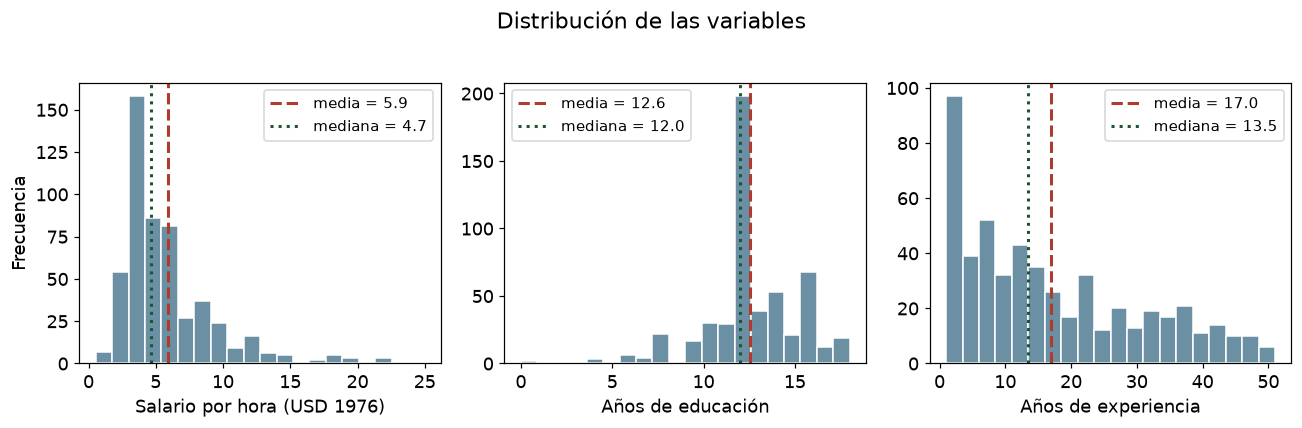

In [5]:
fig, ejes = plt.subplots(1, 3, figsize=(12, 3.8))

variables = [("wage", "Salario por hora (USD 1976)"),
             ("educ", "Años de educación"),
             ("exper", "Años de experiencia")]

for eje, (var, etiqueta) in zip(ejes, variables):
    eje.hist(df[var], bins=20, color="#6B8FA3", edgecolor="white")
    eje.axvline(df[var].mean(), color="#B03A2E", linestyle="--", linewidth=2,
                label=f"media = {df[var].mean():.1f}")
    eje.axvline(df[var].median(), color="#1E5631", linestyle=":", linewidth=2,
                label=f"mediana = {df[var].median():.1f}")
    eje.set_xlabel(etiqueta)
    eje.legend(fontsize=10)

ejes[0].set_ylabel("Frecuencia")
fig.suptitle("Distribución de las variables", y=1.02)
plt.tight_layout()
plt.show()

El salario es **asimétrico a la derecha**: muchos salarios bajos y una cola larga de salarios altos que arrastra la media por encima de la mediana. La experiencia repite el patrón. Esta forma es típica de las variables de ingreso y es la razón por la que en econometría suele modelarse $\log(\text{salario})$ —lo verán en la maestría—. Hoy trabajamos con el salario en niveles para que todo se lea directamente en dólares.

### 3. ¿Cuánto ganan hombres y mujeres? (5–8 min)

El salario es una variable aleatoria. Lo primero es comparar su distribución **condicionada al sexo**: $E(Y \mid \text{mujer})$ frente a $E(Y \mid \text{hombre})$, y lo mismo con la varianza.

In [6]:
# Media, varianza y desviación estándar del salario, por sexo
df.groupby("female")["wage"].agg(["count", "mean", "var", "std"]).round(2)

,count,mean,var,std
female,,,,
0,274,7.10,17.31,4.16
1,252,4.59,6.40,2.53


In [7]:
medias = df.groupby("female")["wage"].mean()

brecha_bruta = medias[0] - medias[1]   # hombres (0) menos mujeres (1)

print(f"Salario medio hombres: ${medias[0]:.2f} por hora")
print(f"Salario medio mujeres: ${medias[1]:.2f} por hora")
print(f"Brecha bruta:          ${brecha_bruta:.2f} por hora")

Salario medio hombres: $7.10 por hora
Salario medio mujeres: $4.59 por hora
Brecha bruta:          $2.51 por hora


Los hombres ganan en promedio **2.51 dólares más por hora** (un 55% más). Veamos las distribuciones completas, no solo las medias:

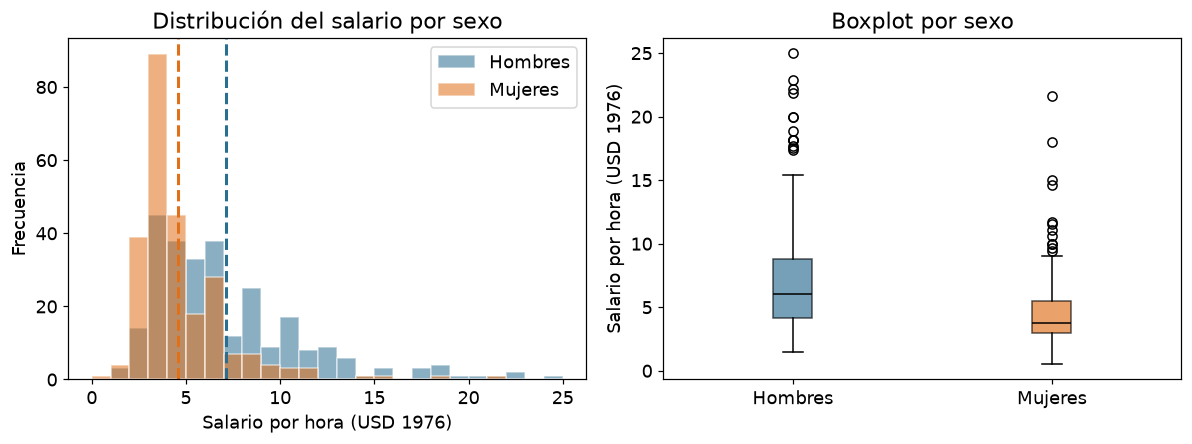

In [8]:
salario_h = df.loc[df["female"] == 0, "wage"]
salario_m = df.loc[df["female"] == 1, "wage"]

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))

# Izquierda: histogramas superpuestos
bins = np.arange(0, 26, 1)
ejes[0].hist(salario_h, bins=bins, alpha=0.55, color=COLOR_H,
             label="Hombres", edgecolor="white")
ejes[0].hist(salario_m, bins=bins, alpha=0.55, color=COLOR_M,
             label="Mujeres", edgecolor="white")
ejes[0].axvline(medias[0], color=COLOR_H, linestyle="--", linewidth=2)
ejes[0].axvline(medias[1], color=COLOR_M, linestyle="--", linewidth=2)
ejes[0].set_xlabel("Salario por hora (USD 1976)")
ejes[0].set_ylabel("Frecuencia")
ejes[0].set_title("Distribución del salario por sexo")
ejes[0].legend()

# Derecha: boxplot
cajas = ejes[1].boxplot(
    [salario_h, salario_m],
    tick_labels=["Hombres", "Mujeres"],
    patch_artist=True,
    medianprops={"color": "black"},
)
for caja, color in zip(cajas["boxes"], [COLOR_H, COLOR_M]):
    caja.set_facecolor(color)
    caja.set_alpha(0.65)
ejes[1].set_ylabel("Salario por hora (USD 1976)")
ejes[1].set_title("Boxplot por sexo")

plt.tight_layout()
plt.show()

Dos hechos saltan a la vista: la distribución de las mujeres está **desplazada a la izquierda** (medianas y medias menores) y es **menos dispersa** (varianza menor, casi sin salarios altos).

**La pregunta clave:** ¿esta brecha demuestra discriminación? Todavía no. Podría ser que hombres y mujeres difieran en educación o experiencia. Para *comparar personas comparables* necesitamos una regresión.

### 4. MCO: un problema nuevo de optimización (8–14 min)

¿De dónde sale la recta que "mejor ajusta"? De un **problema de optimización**, como los que ya resolvieron en el módulo. El modelo lineal en forma matricial es

$$y = X\beta + u,$$

donde $y$ es el vector de salarios ($n \times 1$), $X$ la matriz de diseño (con una columna de unos para el intercepto) y $u$ el error. Para cualquier candidato $\beta$, los residuos son $y - X\beta$. **Mínimos cuadrados ordinarios** elige el $\beta$ que minimiza la suma de sus cuadrados:

$$\min_{\beta}\; J(\beta) = (y - X\beta)'(y - X\beta) = \sum_{i=1}^{n} (y_i - x_i'\beta)^2.$$

Es el mismo tipo de problema que ya conocen —derivar, igualar a cero, verificar segundo orden—, con una novedad: la incógnita ya no es un escalar sino un **vector**.

**Condición de primer orden.** Las reglas de derivación matricial son análogas a las escalares que ya dominan:

| Escalar | Matricial |
|---|---|
| $\dfrac{d}{dx}(ax) = a$ | $\nabla_{\beta}(a'\beta) = a$ |
| $\dfrac{d}{dx}(ax^2) = 2ax$ | $\nabla_{\beta}(\beta'A\beta) = 2A\beta$, con $A$ simétrica |

Expandiendo $J(\beta) = y'y - 2\beta'X'y + \beta'X'X\beta$ y derivando término a término (nótese que $X'X$ es simétrica):

$$\nabla_{\beta} J(\beta) = -2X'y + 2X'X\beta = 0,$$

que produce las **ecuaciones normales**:

$$\boxed{\,X'X\,\beta = X'y\,}$$

Si $X'X$ es invertible, despejar da la fórmula célebre del estimador MCO:

$$\boxed{\,\hat{\beta} = (X'X)^{-1}X'y\,}$$

**Condición de segundo orden.** La Hessiana es $\nabla^2 J = 2X'X$, definida positiva cuando las columnas de $X$ son linealmente independientes. Igual que $f''(x)>0$ garantizaba el mínimo de una parábola, aquí garantiza que $J$ es **convexa** y que $\hat{\beta}$ es el **mínimo global único**.

Y toda la fórmula es álgebra que ya manejan: transpuesta, producto e inversa; es decir, `.T`, `@` y `np.linalg.inv`.

**Primer paso — solo la dummy.** Regresemos el salario únicamente contra `female`:

$$\text{wage}_i = \beta_0 + \delta\,\text{female}_i + u_i$$

In [9]:
y = df["wage"].to_numpy()
n = len(y)

# Matriz X: columna de unos + dummy mujer
X_dummy = np.column_stack([
    np.ones(n),
    df["female"].to_numpy(),
])

print("Dimensión de X:", X_dummy.shape)
X_dummy[:5]

Dimensión de X: (526, 2)


array([[1., 1.],
       [1., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [10]:
# La fórmula de MCO, literalmente
beta_dummy = np.linalg.inv(X_dummy.T @ X_dummy) @ X_dummy.T @ y

print(f"Intercepto (beta_0): {beta_dummy[0]:.2f}")
print(f"Coef. female (delta): {beta_dummy[1]:.2f}")
print()
print(f"Media hombres: {medias[0]:.2f}   ->  igual al intercepto")
print(f"Brecha bruta:  {brecha_bruta:.2f}   ->  igual a -delta")

Intercepto (beta_0): 7.10
Coef. female (delta): -2.51

Media hombres: 7.10   ->  igual al intercepto
Brecha bruta:  2.51   ->  igual a -delta


Con solo dos parámetros, $(\beta_0, \delta)$, podemos *ver* el problema de optimización completo: la superficie de $J$ y el punto exacto donde el gradiente se anula.

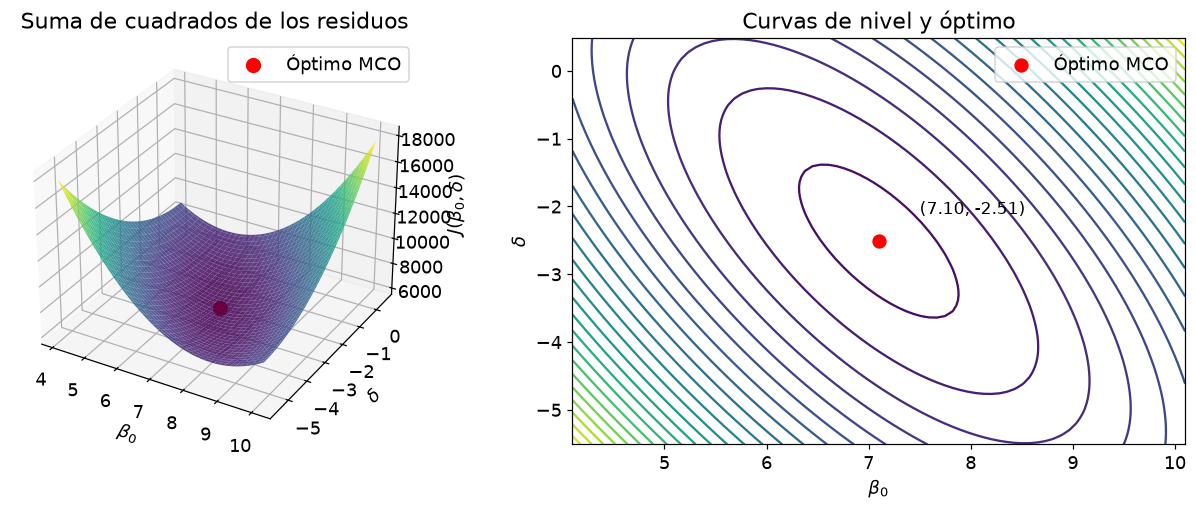

Mínimo en (beta_0, delta) = (7.10, -2.51)
SCR mínima: J = 6332.2


In [11]:
# Superficie de la función objetivo J(beta_0, delta) del modelo con solo la dummy
female_arr = df["female"].to_numpy()

def J(b0, d):
    residuos = y - b0 - d * female_arr
    return residuos @ residuos

b0_grid = np.linspace(beta_dummy[0] - 3, beta_dummy[0] + 3, 80)
d_grid = np.linspace(beta_dummy[1] - 3, beta_dummy[1] + 3, 80)
B0, D = np.meshgrid(b0_grid, d_grid)

J_grid = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        J_grid[i, j] = J(B0[i, j], D[i, j])

fig = plt.figure(figsize=(12, 4.8))

# Izquierda: superficie en 3D
eje3d = fig.add_subplot(1, 2, 1, projection="3d")
eje3d.plot_surface(B0, D, J_grid, cmap="viridis", alpha=0.85)
eje3d.scatter(beta_dummy[0], beta_dummy[1], J(*beta_dummy),
              color="red", s=80, depthshade=False, label="Óptimo MCO")
eje3d.set_xlabel(r"$\beta_0$")
eje3d.set_ylabel(r"$\delta$")
eje3d.set_zlabel(r"$J(\beta_0, \delta)$")
eje3d.set_title("Suma de cuadrados de los residuos")
eje3d.legend()

# Derecha: curvas de nivel
eje2d = fig.add_subplot(1, 2, 2)
eje2d.contour(B0, D, J_grid, levels=25, cmap="viridis")
eje2d.scatter(beta_dummy[0], beta_dummy[1], color="red", s=70, zorder=5,
              label="Óptimo MCO")
eje2d.annotate(f"({beta_dummy[0]:.2f}, {beta_dummy[1]:.2f})",
               xy=(beta_dummy[0], beta_dummy[1]),
               xytext=(beta_dummy[0] + 0.4, beta_dummy[1] + 0.4), fontsize=11)
eje2d.set_xlabel(r"$\beta_0$")
eje2d.set_ylabel(r"$\delta$")
eje2d.set_title("Curvas de nivel y óptimo")
eje2d.legend()

plt.tight_layout()
plt.show()

print(f"Mínimo en (beta_0, delta) = ({beta_dummy[0]:.2f}, {beta_dummy[1]:.2f})")
print(f"SCR mínima: J = {J(*beta_dummy):.1f}")

Un **paraboloide convexo**: un solo valle, un solo fondo, sin óptimos locales donde atascarse. Eso es exactamente lo que garantizaba la Hessiana definida positiva. El fondo del valle está en $(\hat{\beta}_0, \hat{\delta}) = (7.10,\, -2.51)$: **la brecha salarial es la solución de un problema de optimización**. (En la maestría verán que esta misma superficie puede descenderse paso a paso con *descenso por gradiente* —el método con que se entrenan las redes neuronales—; aquí la convexidad permite saltar directo al fondo con la fórmula cerrada.)

**El clic:** además, el intercepto es la media de los hombres y $\hat{\delta} = -2.51$ es exactamente la brecha bruta del `groupby`, con signo negativo. La regresión no es magia nueva: los descriptivos son su caso más simple.

**Segundo paso — controlar por educación y experiencia.** Ahora sí la pregunta interesante: comparar personas con las *mismas* características observables:

$$\text{wage}_i = \beta_0 + \beta_1\,\text{educ}_i + \beta_2\,\text{exper}_i + \delta\,\text{female}_i + u_i$$

In [12]:
# Matriz X completa: unos, educación, experiencia, dummy mujer
X = np.column_stack([
    np.ones(n),
    df["educ"].to_numpy(),
    df["exper"].to_numpy(),
    df["female"].to_numpy(),
])

beta_gorro = np.linalg.inv(X.T @ X) @ X.T @ y

nombres = ["intercepto", "educ", "exper", "female"]
pd.Series(beta_gorro.round(3), index=nombres, name="MCO matricial")

intercepto   -1.734
educ          0.603
exper         0.064
female       -2.156
Name: MCO matricial, dtype: float64

Lectura de los coeficientes, *manteniendo lo demás constante*:

- Un año adicional de educación se asocia con **+\$0.60** por hora.
- Un año adicional de experiencia, con **+\$0.06** por hora.
- Ser mujer se asocia con **−\$2.16** por hora, *aun con la misma educación y experiencia*.

La brecha bajó de 2.51 a 2.16 al controlar: una parte pequeña se explicaba por diferencias en educación y experiencia, pero **la mayor parte persiste**. Veámoslo gráficamente:

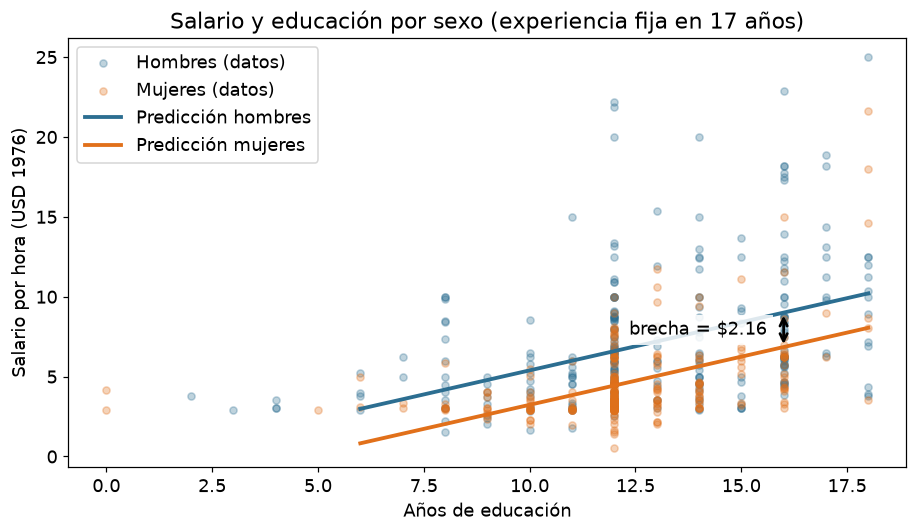

In [13]:
# Rectas predichas: salario vs educación, con experiencia fija en su media.
# El grid va de 6 a 18 años: donde está la masa de los datos.
exper_media = df["exper"].mean()
educ_grid = np.linspace(6, 18, 50)

pred_h = (beta_gorro[0]
          + beta_gorro[1] * educ_grid
          + beta_gorro[2] * exper_media)          # female = 0
pred_m = pred_h + beta_gorro[3]                   # female = 1: misma recta - 2.16

fig, eje = plt.subplots(figsize=(8.5, 5))

# Nube de puntos real, de fondo
eje.scatter(df.loc[df["female"] == 0, "educ"],
            df.loc[df["female"] == 0, "wage"],
            alpha=0.30, s=22, color=COLOR_H, label="Hombres (datos)")
eje.scatter(df.loc[df["female"] == 1, "educ"],
            df.loc[df["female"] == 1, "wage"],
            alpha=0.30, s=22, color=COLOR_M, label="Mujeres (datos)")

# Rectas del modelo
eje.plot(educ_grid, pred_h, color=COLOR_H, linewidth=2.5,
         label="Predicción hombres")
eje.plot(educ_grid, pred_m, color=COLOR_M, linewidth=2.5,
         label="Predicción mujeres")

# Flecha que marca la brecha condicionada
educ_marca = 16
y_h = beta_gorro[0] + beta_gorro[1]*educ_marca + beta_gorro[2]*exper_media
eje.annotate("", xy=(educ_marca, y_h + beta_gorro[3]),
             xytext=(educ_marca, y_h),
             arrowprops={"arrowstyle": "<->", "color": "black", "lw": 1.8})
eje.text(educ_marca - 0.4, y_h + beta_gorro[3]/2,
         f"brecha = ${abs(beta_gorro[3]):.2f}",
         fontsize=12, va="center", ha="right",
         bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"})

eje.set_xlabel("Años de educación")
eje.set_ylabel("Salario por hora (USD 1976)")
eje.set_title(f"Salario y educación por sexo (experiencia fija en {exper_media:.0f} años)")
eje.legend()
plt.tight_layout()
plt.show()

Dos rectas **paralelas** separadas por $\hat{\delta} = -2.16$: eso significa *"manteniendo constante lo demás"*. A cualquier nivel de educación, el modelo predice 2.16 dólares menos por hora para una mujer con la misma experiencia.

### 5. La librería profesional (14–16 min)

En la práctica nadie invierte $X'X$ a mano: se usa una librería. En econometría con Python, la estándar es **statsmodels**. La misma regresión, en tres líneas:

In [14]:
import statsmodels.formula.api as smf

modelo = smf.ols("wage ~ educ + exper + female", data=df).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     77.92
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           1.15e-41
Time:                        21:36:56   Log-Likelihood:                -1335.7
No. Observations:                 526   AIC:                             2679.
Df Residuals:                     522   BIC:                             2697.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7345      0.754     -2.302      0.0

In [15]:
# Los coeficientes son idénticos a los de nuestra fórmula matricial
pd.DataFrame({
    "MCO matricial (a mano)": beta_gorro.round(4),
    "statsmodels": modelo.params.round(4).to_numpy(),
}, index=nombres)

,MCO matricial (a mano),statsmodels
intercepto,-1.7345,-1.7345
educ,0.6026,0.6026
exper,0.0642,0.0642
female,-2.1555,-2.1555


**Coeficientes idénticos hasta el último decimal.** La librería no hace nada distinto: por dentro resuelve $(X'X)^{-1}X'y$, la misma álgebra que ustedes acaban de ejecutar. Lo que agrega el `summary` —errores estándar, estadísticos $t$, valores $p$, intervalos de confianza— es la **inferencia**: cuantificar la incertidumbre de estas estimaciones. Ese es exactamente el corazón de Econometría I en la maestría; hoy ya saben de dónde sale la columna `coef`.

### 6. Dos personas idénticas, salvo el sexo (16–18 min)

La predicción del modelo para una persona con características $x$ es el producto punto $\hat{y} = x'\hat{\beta}$. Comparemos dos perfiles que solo difieren en el sexo: 16 años de educación (título universitario) y 10 de experiencia.

In [16]:
perfil_hombre = np.array([1, 16, 10, 0])   # unos, educ, exper, female
perfil_mujer  = np.array([1, 16, 10, 1])

pred_perfil_h = perfil_hombre @ beta_gorro
pred_perfil_m = perfil_mujer @ beta_gorro

print(f"Salario predicho, hombre: ${pred_perfil_h:.2f} por hora")
print(f"Salario predicho, mujer:  ${pred_perfil_m:.2f} por hora")
print(f"Diferencia:               ${pred_perfil_h - pred_perfil_m:.2f} por hora")

Salario predicho, hombre: $8.55 por hora
Salario predicho, mujer:  $6.39 por hora
Diferencia:               $2.16 por hora


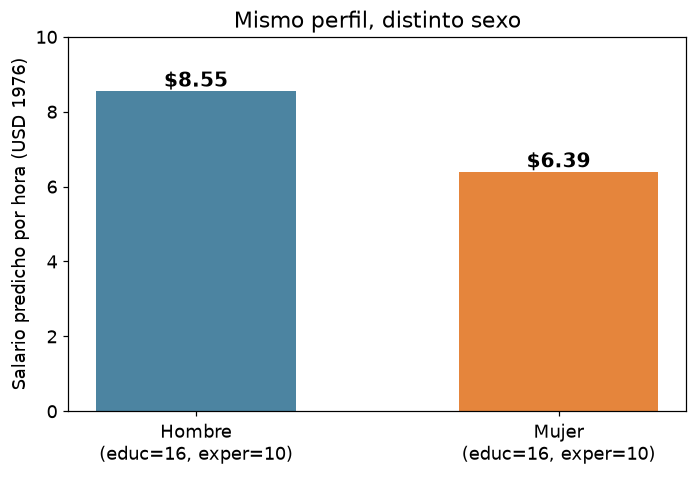

In [17]:
fig, eje = plt.subplots(figsize=(6.5, 4.5))

barras = eje.bar(
    ["Hombre\n(educ=16, exper=10)", "Mujer\n(educ=16, exper=10)"],
    [pred_perfil_h, pred_perfil_m],
    color=[COLOR_H, COLOR_M], alpha=0.85, width=0.55,
)

for barra, valor in zip(barras, [pred_perfil_h, pred_perfil_m]):
    eje.text(barra.get_x() + barra.get_width()/2, valor + 0.12,
             f"${valor:.2f}", ha="center", fontsize=13, fontweight="bold")

eje.set_ylabel("Salario predicho por hora (USD 1976)")
eje.set_title("Mismo perfil, distinto sexo")
eje.set_ylim(0, 10)
plt.tight_layout()
plt.show()

### 7. ¿Brecha = discriminación? (18–20 min)

Cuidado con el salto:

$$\text{brecha condicionada} \neq \text{prueba causal de discriminación}$$

Nuestro $\hat{\delta} = -2.16$ dice que, *según este modelo y estas variables*, mujeres y hombres comparables ganan distinto. Pero el modelo omite ocupación, industria, horas trabajadas, interrupciones de carrera, selección en quién participa del mercado laboral... Cualquiera de esas omisiones podría explicar parte de la brecha —o esconder discriminación adicional.

**¿Cómo se identifica discriminación de verdad?** Con diseño experimental. El estudio clásico es Bertrand y Mullainathan (2004): enviaron miles de CV *idénticos* a empleos reales en EE. UU., cambiando al azar solo el nombre (típicamente blanco vs. típicamente afroamericano). Mismos CV, 50% más llamadas para los nombres blancos. Al aleatorizar el nombre, no queda ninguna variable omitida posible: eso sí es evidencia causal.

**Lo que viene en la maestría** conecta directo con lo de hoy:

- *Econometría*: inferencia sobre $\hat{\beta}$ (los errores estándar y valores $p$ del summary), log-salario y la ecuación de Mincer, descomposición de Oaxaca–Blinder de la brecha.
- *Inferencia causal*: experimentos y cuasi-experimentos, como el de los CV.
- *IA y ciencia de datos*: este mismo flujo —datos, modelo, predicción— a mayor escala.

Todo lo de hoy fue Pandas, NumPy y matrices: **ya tienen la base**. Éxitos en el examen.

---

**Referencias.** Wooldridge, J. M., *Introductory Econometrics: A Modern Approach* (datos `wage1`, CPS 1976). Bertrand, M. y S. Mullainathan (2004), "Are Emily and Greg More Employable Than Lakisha and Jamal?", *American Economic Review*, 94(4).

### Síntesis y para llevar

**Lo aprendido hoy:**

1. Un estudio empírico completo cabe en un flujo: datos → descriptivos → regresión → librería profesional → interpretación.
2. La **brecha bruta** (\$2.51 por hora) sale de un `groupby`; la **brecha condicionada** (\$2.16) sale de una regresión que compara personas comparables. La regresión no es magia: los descriptivos son su caso más simple.
3. MCO es un **problema de optimización convexo**: la Hessiana $2X'X$ es definida positiva, así que $\hat{\beta}=(X'X)^{-1}X'y$ es el mínimo global único de la suma de cuadrados de los residuos.
4. `statsmodels` resuelve la misma álgebra y añade la **inferencia** (errores estándar, estadísticos $t$, valores $p$) — el corazón de Econometría I.
5. Brecha condicionada $\neq$ prueba causal de discriminación: identificar causalidad exige diseño experimental, como el estudio de CV de Bertrand y Mullainathan (2004).

**Caja de herramientas de la sesión:**

| Comando | Qué hace | Dónde lo usamos |
|---|---|---|
| `pd.read_csv("wage1.csv")` | carga el CSV en un DataFrame | sección 1 |
| `df.describe()` | media, desviación, cuartiles de cada variable | sección 2 |
| `df.groupby("female")["wage"].agg([...])` | estadísticos del salario condicionados al sexo | sección 3 |
| `df.loc[df["female"] == 0, "wage"]` | filtra las filas de un grupo | sección 3 |
| `np.column_stack([...])` | arma la matriz de diseño $X$ columna a columna | sección 4 |
| `np.linalg.inv(X.T @ X) @ X.T @ y` | el estimador MCO $\hat{\beta}=(X'X)^{-1}X'y$, literal | sección 4 |
| `smf.ols("wage ~ educ + exper + female", data=df).fit()` | la misma regresión con statsmodels | sección 5 |
| `modelo.summary()` | tabla profesional con la inferencia completa | sección 5 |
| `perfil @ beta_gorro` | predicción como producto punto $x'\hat{\beta}$ | sección 6 |

**Para profundizar:** Wooldridge, caps. 2–4 (regresión simple y múltiple) y cap. 7 (variables *dummy* y la brecha salarial); las referencias completas están al final de la sección 7.